#Prepare Data

In [ ]:
from scipy.io import loadmat
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler

data = loadmat('Xtrain.mat')
train_val = data['Xtrain'].reshape(-1, 1)
#print(len(train_val))
min = train_val.min()
max = train_val.max()
#scale = (train_val - min) / (max - min) replaced it by a function for easier conversion back

#scale the value
scaler = MinMaxScaler(feature_range=(0, 1))
scale = scaler.fit_transform(train_val)


Models

In [ ]:
#initializing models: Simple RNN, LSTM and GRU
class SimpleRNN(nn.Module):
  def __init__(self, input_size, hidden_size, output_size, num_layers = 1):
    super(SimpleRNN, self).__init__()
    self.rnn = nn.RNN(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
    self.fc = nn.Linear(hidden_size, output_size)
  def forward(self, x):
    out, hidden = self.rnn(x)
    return self.fc(out[:, -1, :])

class LSTM(nn.Module):
  def __init__(self, input_size, hidden_size, output_size, num_layers = 1):
    super(LSTM, self).__init__()
    self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
    self.fc = nn.Linear(hidden_size, output_size)
  def forward(self, x):
    out, hidden = self.lstm(x)
    return self.fc(out[:, -1, :])

class GRU(nn.Module):
  def __init__(self, input_size, hidden_size, output_size, num_layers = 1):
    super(GRU, self).__init__()
    self.gru = nn.GRU(input_size = input_size, hidden_size = hidden_size, num_layers = num_layers, batch_first = True)
    self.fc = nn.Linear(hidden_size, output_size)
  def forward(self, x):
    out, hidden = self.gru(x)
    return self.fc(out[:, -1, :])

Sliding window

In [ ]:

#sliding window:
def slide_window(data, length):
  inp = []
  targ = []
  for i in range(len(data) - length):
    inp.append(data[i : i + length])
    targ.append(data[i + length])
  return np.array(inp), np.array(targ)

Create Data loaders

In [ ]:




def get_data_loaders(window_size):
  X, y = slide_window(scale, window_size)
  X = torch.tensor(X, dtype = torch.float32)
  y = torch.tensor(y, dtype=torch.float32)
  total = len(X)
  train_size = int(total * 0.8)
  X_train = X[:train_size]
  y_train = y[:train_size]
  X_val = X[train_size:]
  y_val = y[train_size:]
  batch_size = 64
  train_data = TensorDataset(X_train, y_train)
  val_data = TensorDataset(X_val, y_val)
  train_loader = DataLoader(train_data, batch_size = batch_size, shuffle = True)
  val_loader = DataLoader(val_data, batch_size = batch_size, shuffle = False)
  return train_loader, val_loader

#Train model

In [ ]:
#training models:
def train(model, train_loader, val_loader, learning_rate ,mod_name, epochs = 100):
  loss = nn.MSELoss()
  optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)

  #early stopping parameters
  best_value = 1e8
  best_epoch = 0
  max_patience = 10
  cur_patience = 0

  for epoch in range(1, epochs + 1):
    model.train()
    train_loss = 0.0
    for x_b, y_b in train_loader:
      optimizer.zero_grad()
      pred = model(x_b)
      pred_loss = loss(pred, y_b)
      pred_loss.backward()
      optimizer.step()
      train_loss += pred_loss.item()
    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0.0
    with torch.inference_mode():
      for x_b, y_b in val_loader:
        pred = model(x_b)
        val_loss += loss(pred, y_b).item()
      val_loss /= len(val_loader)

    if val_loss < best_value:
      best_value = val_loss
      best_epoch = epoch
      cur_patience = 0
      torch.save(model.state_dict(), f"{mod_name}_model.pth")
    else:
      cur_patience += 1
      if cur_patience >= max_patience:
        print("Early stopping at epoch: " + str(epoch))
        break
    if epoch % 5 == 0:
      print(f"Epoch", epoch, "-- train: ", round(train_loss, 5), "-- val: ", round(val_loss, 10), "-- best val: ", round(best_value, 5), "-- from epoch: ", best_epoch)

  model.load_state_dict(torch.load(f"{mod_name}_model.pth"))
  return model

def evaluate_model(model, val_loader):
  predicted_values = []
  actual_values = []

  criterion = nn.MSELoss()
  l1_loss = nn.L1Loss() #Mean Absolute error loss
  model.eval()
  with torch.inference_mode():
      mse_loss = 0
      mae_loss = 0

      for batch_X, batch_y in val_loader:
        outputs = model(batch_X.float())

        targets = batch_y.float().view_as(outputs)
        loss = criterion(outputs, targets)
        mse_loss += loss.item()

        m_loss = l1_loss(outputs, targets)
        mae_loss += m_loss.item()
        predicted_values.extend(outputs.cpu().numpy())
        actual_values.extend(targets.cpu().numpy())

  return (mse_loss / len(val_loader),mae_loss / len(val_loader),predicted_values,actual_values)

In [ ]:
import pandas as pd

model_classes = [SimpleRNN,LSTM,GRU] #the classes of the models

learning_rates = [0.001,0.01] #https://www.kdnuggets.com/2022/12/tuning-adam-optimizer-parameters-pytorch.html
hidden_sizes = [64]
num_layers = [1]
epochs = [100]
time_steps = [5,10,20,30,50, 100] #the amount of previous laser values the model knows

model_performance = []

for model_class in model_classes:
  for time in time_steps:
    train_loader,val_loader = get_data_loaders(time)
    for learning_rate in learning_rates:
      for hidden_size in hidden_sizes:
        for n_layer in num_layers:
          for epoch in epochs:
            #create and train model
            model = model_class(input_size=1, hidden_size=hidden_size, output_size=1, num_layers=n_layer)
            mod_name = f"{model_class.__name__}_ts{time}_lr{learning_rate}_hl{hidden_size}_nl{n_layer}"
            training_losses = train(model, train_loader, val_loader, learning_rate, mod_name, epoch)

            #evaluate model
            mse,mae ,_ ,_ = evaluate_model(model, val_loader)
            print(f'Model: {model_class.__name__}, window={time}, lr={learning_rate}, mse={mse:.5f}, mae={mae:.5f}')
            model_performance.append({
                'model' : model_class.__name__,
                'learning_rate' : learning_rate,
                'hidden_size' : hidden_size,
                'num_layers' : n_layer,
                'epochs' : epoch,
                'time_steps' : time,
                'mse' : mse,
                'mae' : mae
                })

performance_pd = pd.DataFrame(model_performance)
df_sorted = performance_pd.sort_values(by='mse', ascending=True)
print("\n Top 5: ")
print(df_sorted[['model', 'learning_rate', 'time_steps', 'mse', 'mae']].head(5))
best_mod = df_sorted.iloc[0]
best_lr = best_mod['learning_rate']
best_ts = best_mod['time_steps']
print(f"Best: {best_mod['model']}, lr={best_lr}, time steps = {best_ts}, mse={best_mod['mse']:.5f}, mae={best_mod['mae']:.5f}")

Epoch 5 -- train:  0.01408 -- val:  0.0077670407 -- best val:  0.00777 -- from epoch:  5
Epoch 10 -- train:  0.01148 -- val:  0.0055577916 -- best val:  0.00556 -- from epoch:  10
Epoch 15 -- train:  0.00988 -- val:  0.0044328304 -- best val:  0.00443 -- from epoch:  15
Epoch 20 -- train:  0.01032 -- val:  0.0045075112 -- best val:  0.00409 -- from epoch:  17
Epoch 25 -- train:  0.0099 -- val:  0.0044653163 -- best val:  0.00409 -- from epoch:  17
Early stopping at epoch: 27
Model: SimpleRNN, window=5, lr=0.001, mse=0.00409, mae=0.04622
Epoch 5 -- train:  0.00995 -- val:  0.0049943703 -- best val:  0.00402 -- from epoch:  3
Epoch 10 -- train:  0.00971 -- val:  0.0077376587 -- best val:  0.00402 -- from epoch:  3
Epoch 15 -- train:  0.00915 -- val:  0.0041160618 -- best val:  0.00379 -- from epoch:  12
Epoch 20 -- train:  0.00787 -- val:  0.0041634193 -- best val:  0.00276 -- from epoch:  18
Epoch 25 -- train:  0.0061 -- val:  0.0024426845 -- best val:  0.00115 -- from epoch:  24
Epoch 

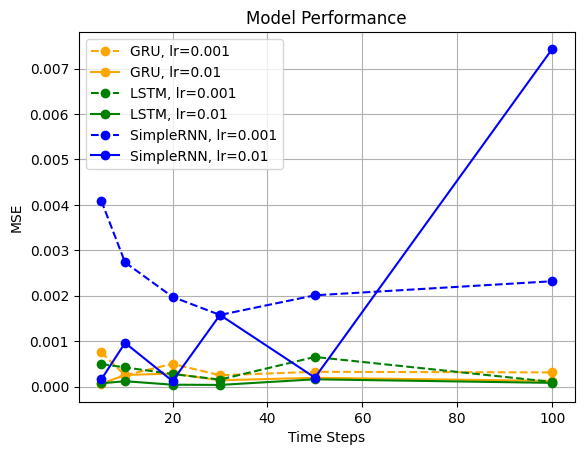

In [ ]:
import matplotlib.pyplot as plt
plt.figure()

model_colors = {
    "SimpleRNN": "blue",
    "LSTM": "green",
    "GRU": "orange"
}

for (model, lr), subset in performance_pd.groupby(["model","learning_rate"]):
    linestyle = "--" if lr == 0.001 else "-"
    plt.plot(
        subset["time_steps"],
        subset["mse"],
        marker='o',
        linestyle=linestyle,
        color=model_colors[model],
        label=f"{model}, lr={lr}"
    )

plt.xlabel("Time Steps")
plt.ylabel("MSE")
plt.title("Model Performance")
plt.legend()
plt.grid(True)

plt.show()

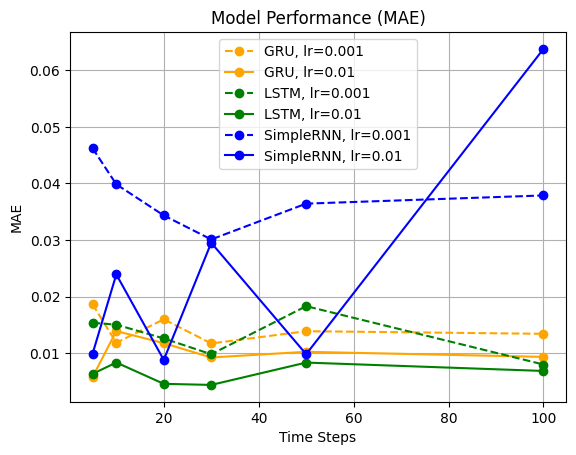

In [ ]:

plt.figure()

for (model, lr), subset in performance_pd.groupby(["model","learning_rate"]):
    linestyle = "--" if lr == 0.001 else "-"
    plt.plot(
        subset["time_steps"],
        subset["mae"],
        marker='o',
        linestyle=linestyle,
        color=model_colors[model],
        label=f"{model}, lr={lr}"
    )

plt.xlabel("Time Steps")
plt.ylabel("MAE")
plt.title("Model Performance (MAE)")
plt.legend()
plt.grid(True)

plt.show()

#Train final model

In [ ]:
# model = LSTM(input_size=1, hidden_size=64, output_size=1, num_layers=best_mod['num_layers'])

In [ ]:
best_hid = best_mod['hidden_size']
best_lay = best_mod['num_layers']
best_epochs = best_mod['epochs']
best_mod_class = {'SimpleRNN': SimpleRNN,'LSTM': LSTM, 'GRU': GRU}
best_model_class = best_mod_class[best_mod['model']]

print(f"Best model: {best_mod['model']}, lr={best_lr}, ts={best_ts}")

train_loader, val_loader = get_data_loaders(best_ts)
best_model = best_model_class(input_size=1, hidden_size= int(best_hid), output_size=1, num_layers=int(best_lay))
best_model = train(best_model, train_loader, val_loader, best_lr, f"{best_mod['model']}_best", best_epochs)




Best model: LSTM, lr=0.01, ts=30
Epoch 5 -- train:  0.01232 -- val:  0.0059585819 -- best val:  0.00596 -- from epoch:  5
Epoch 10 -- train:  0.00456 -- val:  0.0008770896 -- best val:  0.00088 -- from epoch:  10
Epoch 15 -- train:  0.00285 -- val:  0.000469621 -- best val:  0.00047 -- from epoch:  15
Epoch 20 -- train:  0.00198 -- val:  0.0002301452 -- best val:  0.00015 -- from epoch:  19
Epoch 25 -- train:  0.00334 -- val:  0.0007426531 -- best val:  0.00015 -- from epoch:  19
Epoch 30 -- train:  0.00135 -- val:  0.0002233579 -- best val:  0.00015 -- from epoch:  29
Epoch 35 -- train:  0.00065 -- val:  0.0002241655 -- best val:  0.00013 -- from epoch:  32
Epoch 40 -- train:  0.00064 -- val:  0.0002294472 -- best val:  0.00013 -- from epoch:  32
Epoch 45 -- train:  0.00043 -- val:  0.0001008751 -- best val:  6e-05 -- from epoch:  41
Epoch 50 -- train:  0.00032 -- val:  0.0001398552 -- best val:  5e-05 -- from epoch:  48
Epoch 55 -- train:  0.00025 -- val:  6.34677e-05 -- best val:  5

prepare testing data

#C print next 200 steps

In [ ]:
def predict_sequence(model, first_sequence,sequence_length):
  predictions = []

  data = first_sequence.view(1, -1, 1)

  with torch.inference_mode():
    for i in range(sequence_length):
      pred_next = model(data.float())
      predictions.append(pred_next.item())


      new_point = pred_next.view(1, 1, 1)

            # Slide the window
      data = torch.cat((data[:, 1:, :], new_point), dim=1)

  predictions_array = np.array(predictions).reshape(-1, 1)
  return scaler.inverse_transform( predictions_array)

last_window = val_loader.dataset.tensors[0][-1] #not 100% sure what the start should be here
pred = predict_sequence(best_model,last_window,200)
print(pred)

[[ 23.53695658]
 [ 73.79782754]
 [181.86006975]
 [124.18123084]
 [ 37.08022946]
 [ 15.94246433]
 [ 11.55205775]
 [ 12.84844174]
 [ 28.90959357]
 [101.16265163]
 [195.37670386]
 [ 92.65775678]
 [ 26.90653367]
 [ 13.47189881]
 [ 10.56600551]
 [ 12.87931422]
 [ 33.32161164]
 [121.54310229]
 [194.23376238]
 [ 74.53247115]
 [ 22.24707771]
 [ 12.25669975]
 [ 10.04571903]
 [ 12.90471078]
 [ 36.21335332]
 [134.39814019]
 [191.36087632]
 [ 65.32194656]
 [ 19.96839733]
 [ 11.59970953]
 [  9.70437437]
 [ 12.66291469]
 [ 36.91277011]
 [139.30688322]
 [191.54035819]
 [ 62.13625658]
 [ 19.06810397]
 [ 11.28354937]
 [  9.4746809 ]
 [ 12.16028216]
 [ 35.4199242 ]
 [136.3926931 ]
 [195.64539886]
 [ 63.81721386]
 [ 19.2327773 ]
 [ 11.23947249]
 [  9.36649622]
 [ 11.57974647]
 [ 32.58531865]
 [127.58735991]
 [202.11362243]
 [ 69.59871799]
 [ 20.29190427]
 [ 11.39979618]
 [  9.34853314]
 [ 11.00935866]
 [ 29.17321792]
 [115.32637501]
 [209.25495577]
 [ 79.0361585 ]
 [ 22.09540521]
 [ 11.67143649]
 [  9.34

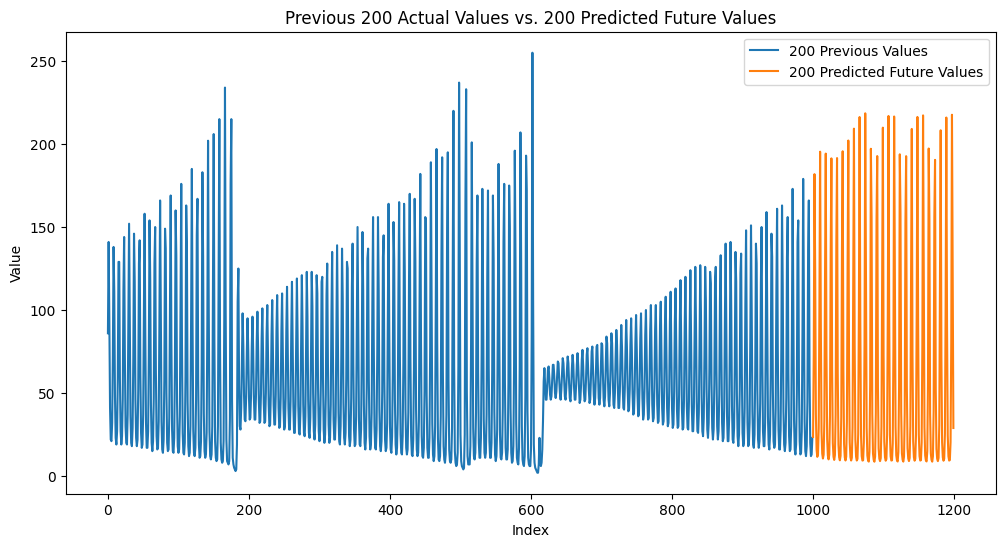

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

last_x_training = 1000
last_x_actual_scaled = scale[-last_x_training:]
last_x_actual = scaler.inverse_transform(last_x_actual_scaled)

x_common = np.arange(last_x_training)
x_future = np.arange(last_x_training, last_x_training + len(pred))

plt.figure(figsize=(12, 6))
plt.plot(x_common, last_x_actual, label='200 Previous Values')
plt.plot(x_future, pred, label='200 Predicted Future Values')

plt.title('Previous 200 Actual Values vs. 200 Predicted Future Values')
plt.xlabel('Index')
plt.ylabel('Value')
plt.legend()
plt.show()

#D Evaluations

load in the test data

In [ ]:
#place to add test data when we have it


test_data = loadmat('Xtest.mat')
test_data = test_data['Xtest'].reshape(-1, 1)
scaled_test_data = scaler.transform(test_data)


comb = np.concatenate([scale[-best_ts:], scaled_test_data])
t_X , t_y = slide_window(comb, best_ts)
t_X = torch.tensor(t_X, dtype = torch.float32)
t_y = torch.tensor(t_y, dtype=torch.float32)

test_data = TensorDataset(t_X, t_y)

test_loader = DataLoader(test_data, batch_size = 64, shuffle = False)  #batch size








plot actual vs predicted and print mse and mae

mse = 17.015308380126953
mae = 2.070707321166992


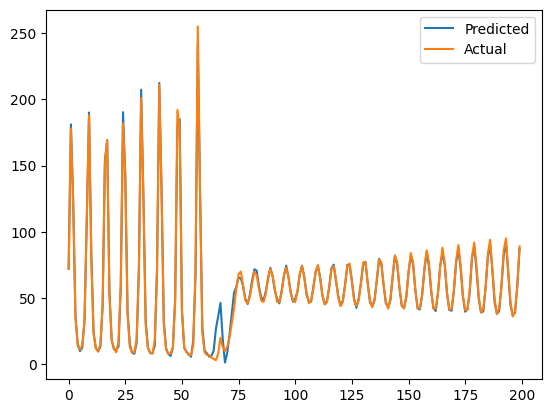

In [ ]:
import matplotlib.pyplot as plt
mse_m, mae_m, predicted, actual = evaluate_model(best_model, test_loader) #replace val loader by correct one

#print(mse_m)
#print(mae_m)

actual = scaler.inverse_transform(np.array(actual).reshape(-1, 1))
predicted = scaler.inverse_transform(np.array(predicted).reshape(-1, 1))

mse = np.mean((predicted - actual)**2)
mae = np.mean(np.abs(predicted-actual))

plt.plot(predicted, label='Predicted')
plt.plot(actual, label='Actual')

plt.legend()

print(f"mse = {mse}")
print(f"mae = {mae}")

Handy other plots

In [ ]:
#plot learning curve

